# 파킨슨병 진단 딥러닝 프로젝트 (Parkinson's Disease Deep Learning Project)

이 노트북은 UCI 파킨슨병 데이터셋을 사용하여 음성 특징 기반의 분류 모델을 구축하는 과정을 담고 있습니다.

## 단계별 구성:
1. **Phase 1: 데이터 탐색 및 전처리 (EDA & Transformations)**
2. **Phase 2: 베이스라인 모델 비교 (Baseline Comparison)**
3. **Phase 3: 딥러닝 아키텍처 설계 및 최적화 (Deep Learning)**
4. **Phase 4: 모델 평가 및 설명력 분석 (Evaluation & Explainability)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import shap

# 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'NanumGothic' # 환경에 따라 변경 필요
plt.rcParams['axes.unicode_minus'] = False

c:\Programming\Workspace\Bootcamp\week3\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Phase 1: Exploratory Data Analysis (EDA) & Transformations

데이터를 로드하고, 분포를 확인하며 필요한 변환을 수행합니다.

In [2]:
# 데이터 로드 (UCI Repository)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
df = pd.read_csv(url)

# 기본 클리닝: 'name' 컬럼 제거 (환자 식별자이므로 학습에 불필요)
df_clean = df.drop('name', axis=1)

print(f"데이터 크기: {df_clean.shape}")
df_clean.head()

데이터 크기: (195, 23)


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

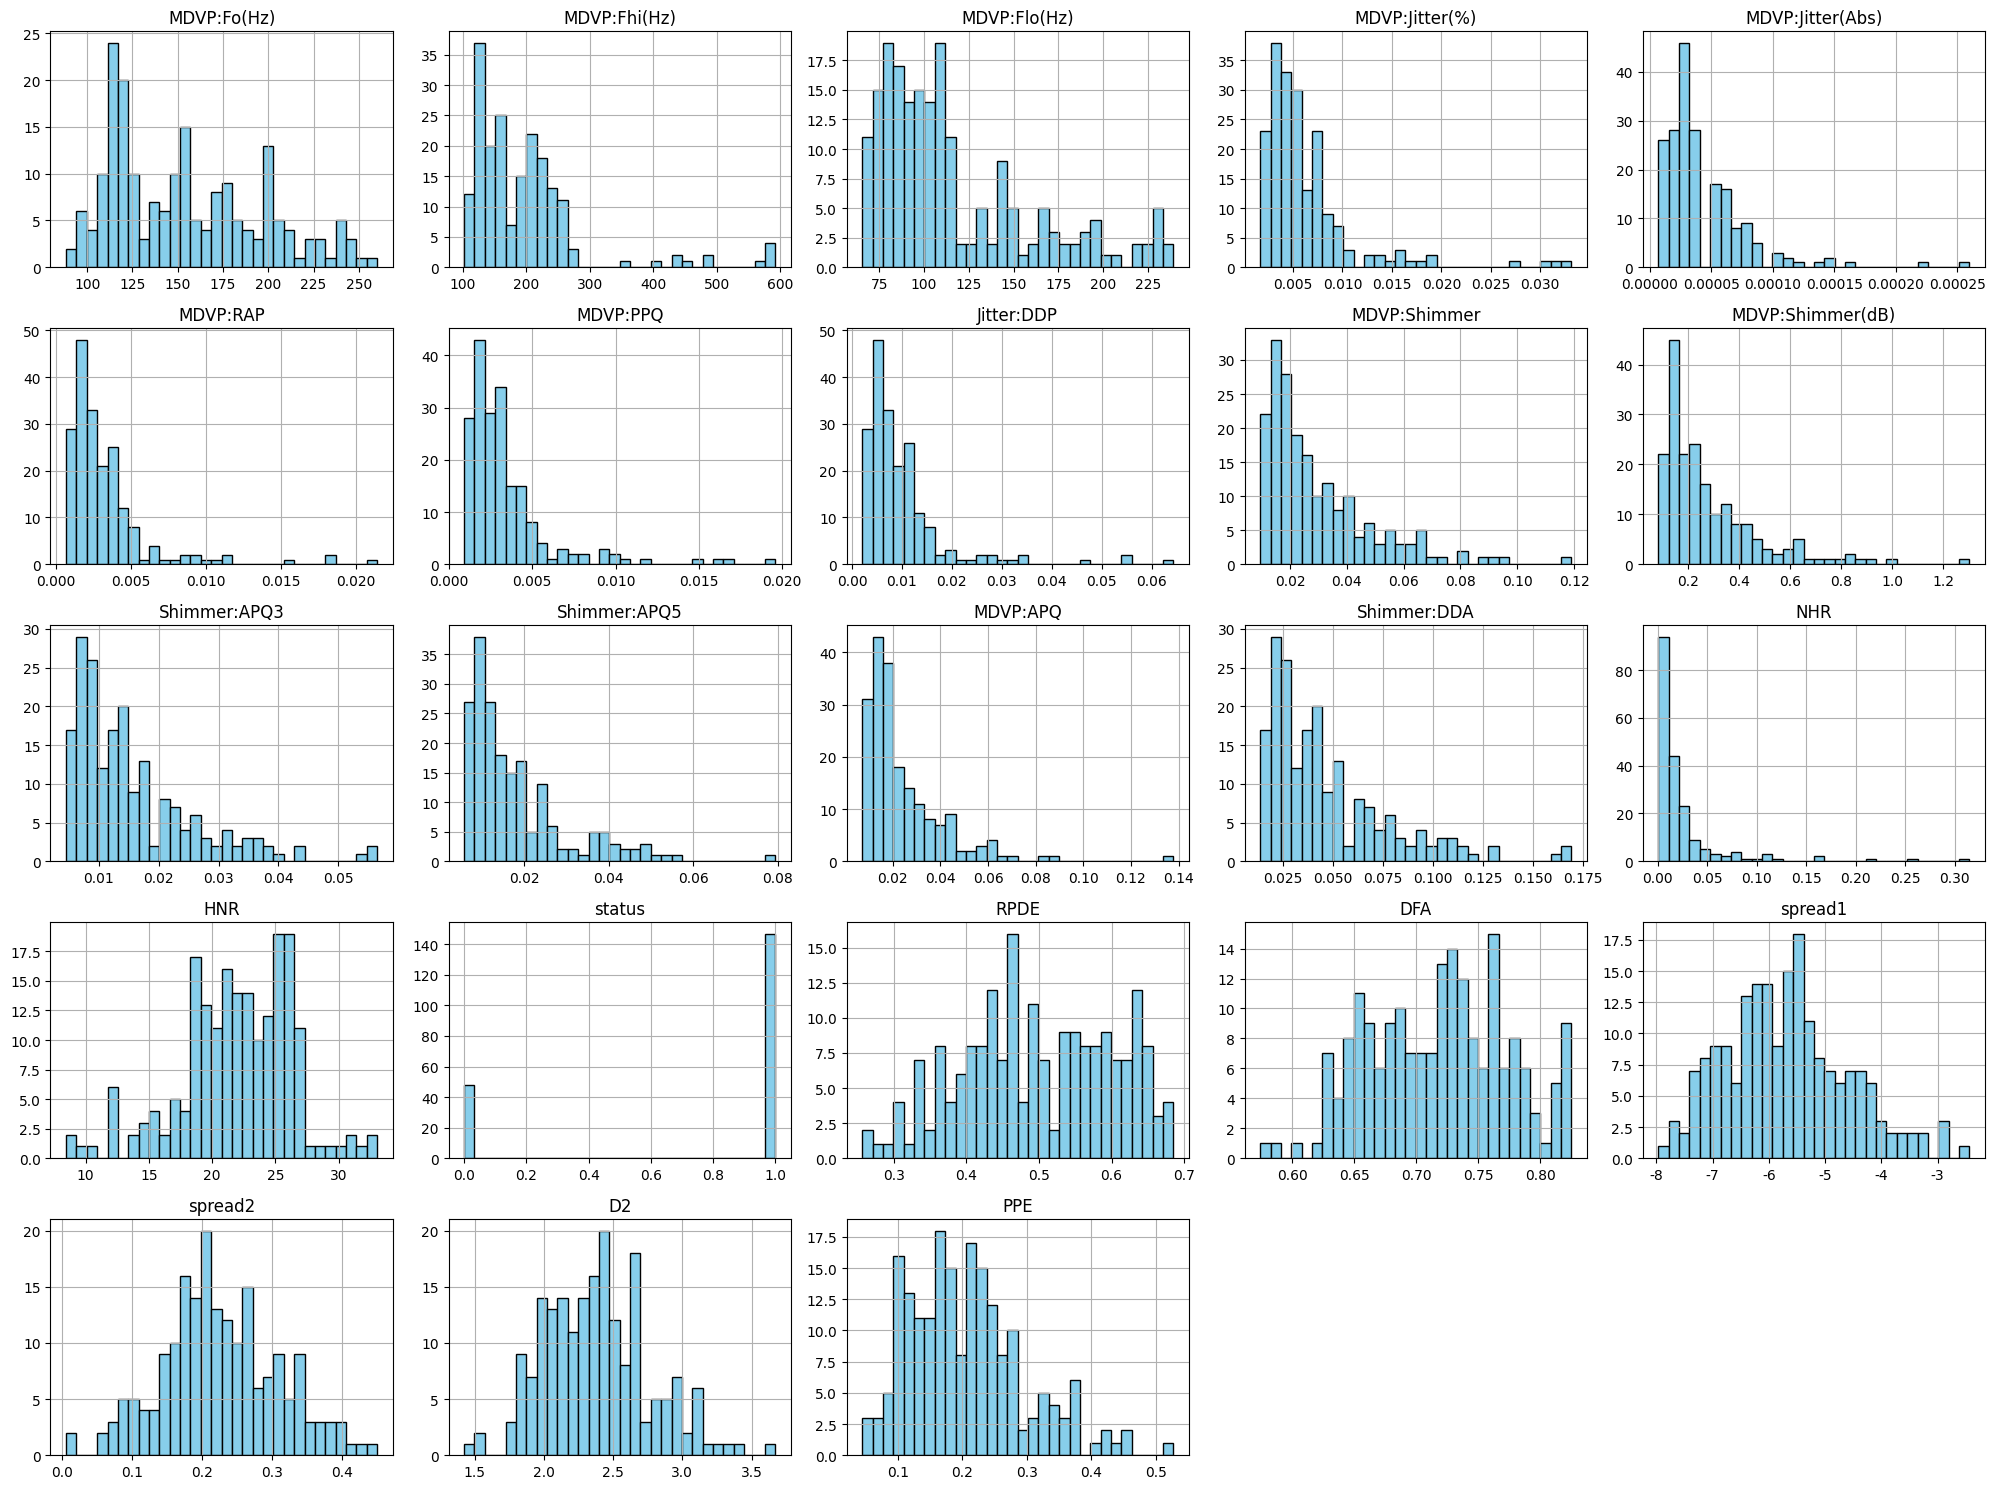

In [3]:
# 히스토그램 시각화 (음성 특징들의 분포 확인)
df_clean.hist(figsize=(20, 15), bins=30, color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

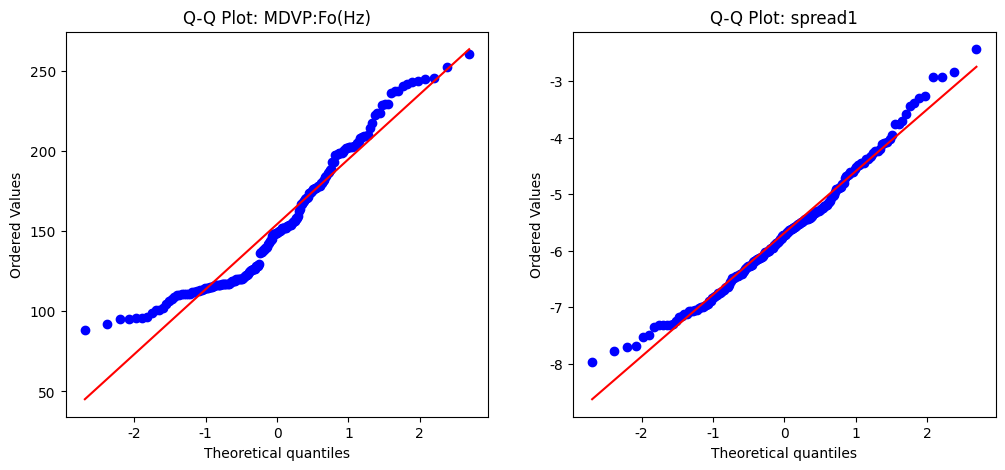

In [4]:
# Q-Q Plot (정규성 확인)
features_to_check = ['MDVP:Fo(Hz)', 'spread1']

plt.figure(figsize=(12, 5))
for i, col in enumerate(features_to_check):
    plt.subplot(1, 2, i+1)
    stats.probplot(df_clean[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot: {col}')
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

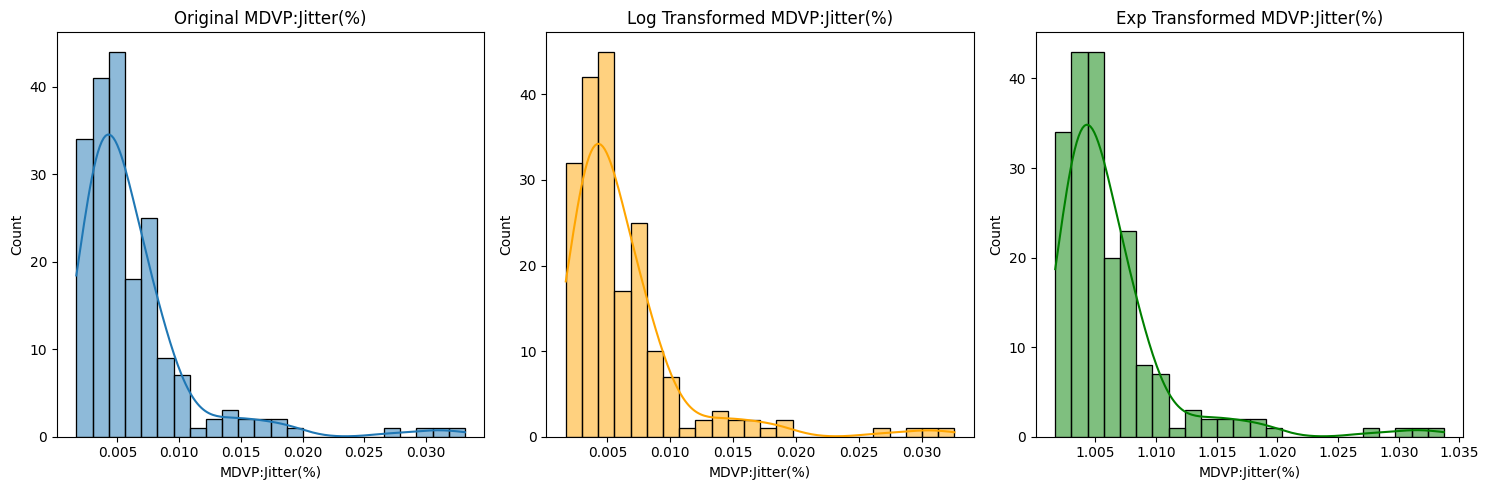

In [5]:
# 로그 및 지수 변환 (왜도가 높은 피처 대상)
# 예시: 'MDVP:Jitter(%)'는 보통 오른쪽으로 치우친 분포를 가짐
target_feature = 'MDVP:Jitter(%)'

plt.figure(figsize=(15, 5))

# 원본
plt.subplot(1, 3, 1)
sns.histplot(df_clean[target_feature], kde=True)
plt.title(f'Original {target_feature}')

# 로그 변환
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df_clean[target_feature]), kde=True, color='orange')
plt.title(f'Log Transformed {target_feature}')

# 지수 변환 (비교용)
plt.subplot(1, 3, 3)
sns.histplot(np.exp(df_clean[target_feature]), kde=True, color='green')
plt.title(f'Exp Transformed {target_feature}')

plt.tight_layout()
plt.show()

## Phase 2: Baseline Model Comparison

전통적인 머신러닝 모델을 학습시켜 기준 성능을 설정합니다.

In [6]:
# 데이터 분할
X = df_clean.drop('status', axis=1)
y = df_clean['status']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 스케일링 (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("데이터 분할 및 스케일링 완료")

데이터 분할 및 스케일링 완료


In [7]:
# 베이스라인 모델 학습
lr = LogisticRegression()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

print(f"Logistic Regression Accuracy: {lr.score(X_val_scaled, y_val):.4f}")
print(f"Random Forest Accuracy: {rf.score(X_val_scaled, y_val):.4f}")

# 최적 베이스라인 모델 리포트
y_pred_rf = rf.predict(X_val_scaled)
print("\n[Random Forest Classification Report]")
print(classification_report(y_val, y_pred_rf))

Logistic Regression Accuracy: 0.9231
Random Forest Accuracy: 0.9231

[Random Forest Classification Report]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



## Phase 3: Deep Learning Architecture & Optimization

TensorFlow/Keras를 사용하여 심층 신경망을 구축합니다.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

def build_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 하이퍼파라미터 설정
BATCH_SIZE = 16
EPOCHS = 100

model = build_model(X_train_scaled.shape[1])

# Early Stopping 설정
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 학습
history = model.fit(
    X_train_scaled, y_train, 
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

c:\Programming\Workspace\Bootcamp\week3\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3718 - loss: 0.9779 - val_accuracy: 0.7436 - val_loss: 0.6431
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4808 - loss: 0.8472 - val_accuracy: 0.7692 - val_loss: 0.6163
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6090 - loss: 0.7183 - val_accuracy: 0.8205 - val_loss: 0.5905
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7179 - loss: 0.5665 - val_accuracy: 0.8205 - val_loss: 0.5636
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6987 - loss: 0.5508 - val_accuracy: 0.8974 - val_loss: 0.5362
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7756 - loss: 0.4800 - val_accuracy: 0.9231 - val_loss: 0.5119
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7756 - loss: 0.4602 - val_accuracy: 0.9231 - val_loss: 0.4876
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7692 - loss: 0.4571 - val_accuracy: 0.

## Phase 4: Evaluation & Explainability

모델의 성능을 다각도로 평가하고 SHAP을 통해 결과를 해석합니다.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

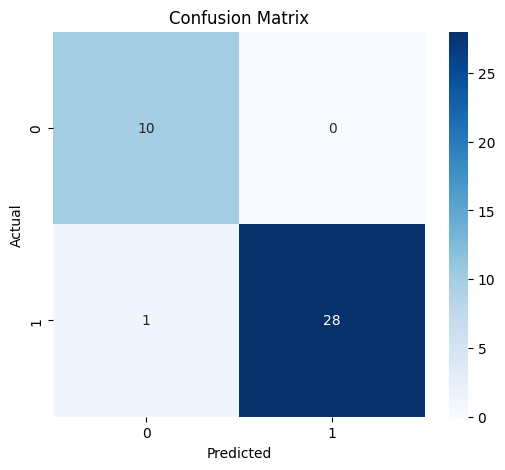

In [9]:
# 예측 및 평가
y_pred_prob = model.predict(X_val_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

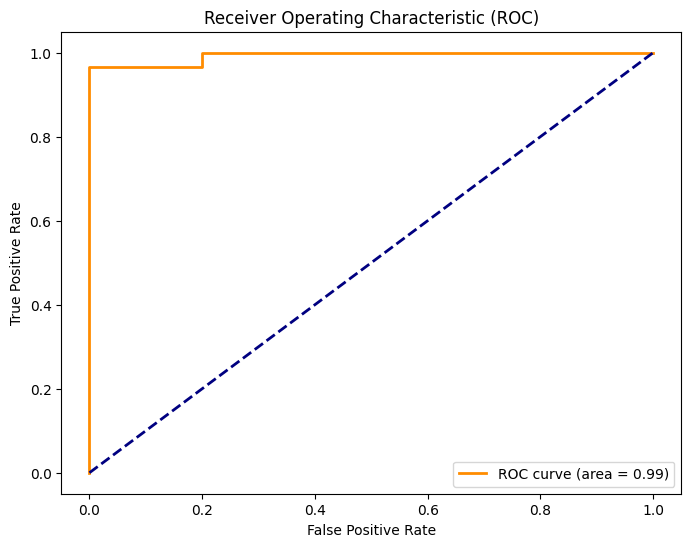

In [10]:
# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

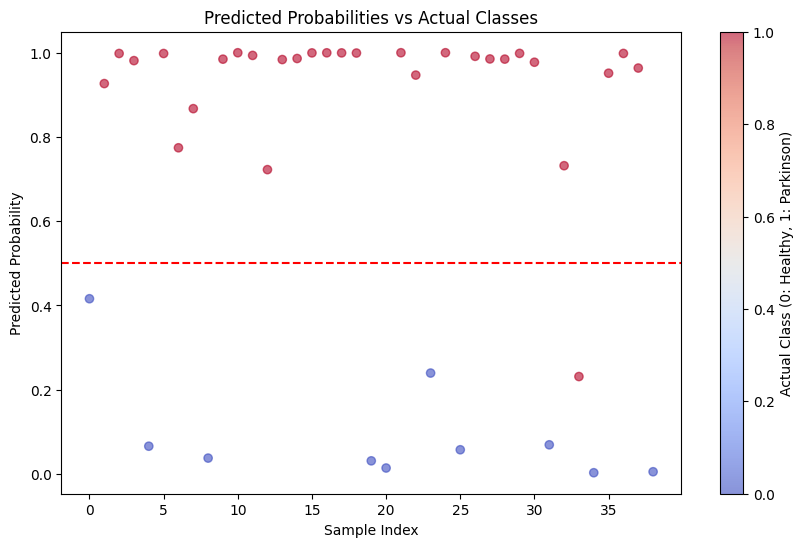

In [11]:
# 예측 확률 vs 실제 클래스 산점도
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_val)), y_pred_prob, c=y_val, cmap='coolwarm', alpha=0.6)
plt.axhline(0.5, color='red', linestyle='--')
plt.title('Predicted Probabilities vs Actual Classes')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Probability')
plt.colorbar(label='Actual Class (0: Healthy, 1: Parkinson)')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
3269/3269 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


  5%|▌         | 1/20 [00:05<01:48,  5.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
3269/3269 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


...

 90%|█████████ | 18/20 [01:42<00:11,  5.93s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
3269/3269 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


 95%|█████████▌| 19/20 [01:48<00:05,  5.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3269/3269 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


100%|██████████| 20/20 [01:54<00:00,  5.70s/it]
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fo

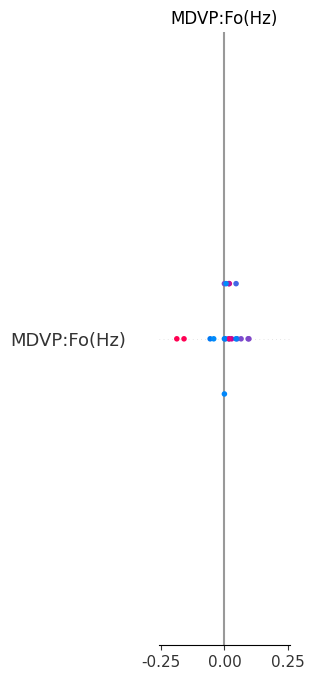

In [12]:
# SHAP을 이용한 모델 설명
# 딥러닝 모델의 경우 KernelExplainer나 DeepExplainer 사용
explainer = shap.KernelExplainer(model.predict, X_train_scaled[:50]) # 속도를 위해 일부 샘플 사용
shap_values = explainer.shap_values(X_val_scaled[:20])

shap.summary_plot(shap_values, X_val_scaled[:20], feature_names=X.columns)